<a href="https://colab.research.google.com/github/r73psv/univer/blob/master/NetworkX_%D0%92%D0%B2%D0%B5%D0%B4%D0%B5%D0%BD%D0%B8%D0%B5_ipynb__.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Установка необходимых библиотек
!pip install networkx matplotlib numpy pandas scipy

In [ ]:
!pip install torch-geometric

Эго‑сеть - это подграф социального графа, где центральная вершина («эго») -  выбранный персонаж, а остальные вершины («альтер‑эго») -  персонажи, с которыми он взаимодействует.

Мы будем строить эго-сеть главного героя Пьера Безухого, поскольку его роль достаточно велика, а также интересны именно его взаимоотношения с другими ключевыми фигурами романа.

In [ ]:
# импорт библиотек
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

Эго‑сеть — подграф, центрированный вокруг «эго» (в нашем случае — Пьер Безухов), включающий:
Эго — центральная вершина (Пьер).
Альтер‑вершины — персонажи, напрямую связанные с Пьером.
Связи между альтерами — если они есть в данных.
Создаём граф G с вершинами (персонажи) и рёбрами (связи).
Для каждого отношения добавляем ребро с атрибутами:

weight — вес связи (от 1 до 10):
отражает интенсивность отношений:

1–3: слабые связи (знакомые, эпизодические встречи);

4–6: умеренные связи (светские отношения, деловые контакты);

7–8: сильные связи (дружба, родство, вражда);

9–10: ключевые связи (любовь, глубокая дружба, кровное родство).

type — тип связи (строка):
определяет род взаимодействия:
родственники (семья, кузины, сёстры/братья);
друзья (духовная близость, взаимная поддержка);
враги (вражда, дуэль, политические противоречия);
супруги/влюблённые;
наставники/ученики;
сослуживцы/товарищи по службе;
светские знакомые.

 centrality(важность) — показывает важность персонажа в общем сюжете:

Высокая: ключевые герои, вокруг которых строится основная сюжетная линия (Пьер, Андрей, Наташа, Николай);

Средняя: важные, но второстепенные персонажи, влияющие на развитие сюжета (Элен, Анатоль, Долохов, Марья);

Низкая: эпизодические персонажи (например, офицеры, слуги, гости на балах).
.

In [ ]:
# Данные для анализа (получены с использованием нейросети Алиса Ai)
# Герои и их важность
characters = [
    ("Пьер Безухов", "Высокая"),
    ("Андрей Болконский","Высокая"),
    ("Элен Курагина", "Высокая"),
    ("Наташа Ростова", "Высокая"),
    ("Долохов", "Средняя"),
    ("Платон Каратаев", "Средняя"),
    ("Анна Павловна Шерер", "Средняя"),
    ("Сперанский", "Средняя"),
    ("Василий Курагин", "Средняя"),
    ("Марья Болконская", "Высокая"),
    ("Княжна Лиза Болконская", "Средняя"),
    ("Тушин", "Средняя"),
    ("Николай Ростов", "Высокая"),
    ("Соня Ростова", "Средняя"),
    ("Анатоль Курагин", "Средняя"),
    ("Денисов", "Средняя"),
    ("Борис Друбецкой", "Средняя"),
    ("Василий Курагин", "Средняя"),
    ("Анна Михайловна Друбецкая", "Средняя"),
    ("Жюли Карагина", "Средняя"),
    ("Илья Андреевич Ростов", "Средняя"),
    ("Наталья Ростова (мать)", "Средняя"),
    ("Вера Ростова", "Средняя"),
    ("Берг", "Средняя")
    ]
# Связи между героями
edges = [
    # Прямые связи Пьера
    ("Пьер Безухов", "Андрей Болконский", 8, "Друзья"),
    ("Пьер Безухов", "Элен Курагина", 7, "Супруги"),
    ("Пьер Безухов", "Наташа Ростова", 10, "Любовь/супруги"),
    ("Пьер Безухов", "Долохов", 6, "Вражда"),
    ("Пьер Безухов", "Платон Каратаев", 8, "Духовное наставничество"),
    ("Пьер Безухов", "Анна Павловна Шерер", 5, "Светское знакомство"),
    ("Пьер Безухов", "Сперанский", 7, "Идейное влияние"),
    ("Пьер Безухов", "Василий Курагин", 4, "Светское знакомство"),

    # Связи Андрея Болконского (расширяют сеть Пьера через Андрея)
    ("Андрей Болконский", "Марья Болконская", 9, "Брат и сестра"),
    ("Андрей Болконский", "Княжна Лиза Болконская", 9, "Супруги"),
    ("Андрей Болконский", "Тушин", 7, "Товарищи по службе"),

    # Связи Наташи Ростовой
    ("Наташа Ростова", "Николай Ростов", 9, "Брат и сестра"),
    ("Наташа Ростова", "Соня Ростова", 8, "Кузины/подруги"),
    ("Наташа Ростова", "Анатоль Курагин", 7, "Влечение/искушение"),

    # Связи Николая Ростова
    ("Николай Ростов", "Денисов", 8, "Наставник/ученик"),
    ("Николай Ростов", "Борис Друбецкой", 6, "Друзья/сослуживцы"),

    # Семейство Курагиных
    ("Элен Курагина", "Василий Курагин", 9, "Отец и дочь"),
    ("Анатоль Курагин", "Василий Курагин", 9, "Отец и сын"),
    ("Анатоль Курагин", "Долохов", 7, "Друзья"),

    # Связи Бориса Друбецкого
    ("Борис Друбецкой", "Анна Михайловна Друбецкая", 9, "Мать и сын"),
    ("Борис Друбецкой", "Жюли Карагина", 5, "Светские знакомые"),

    # Связи семьи Ростовых
    ("Илья Андреевич Ростов", "Наталья Ростова (мать)", 9, "Супруги"),
    ("Вера Ростова", "Наташа Ростова", 9, "Сёстры"),
    ("Вера Ростова", "Берг", 8, "Супруги"),

    # Светское общество
    ("Анна Павловна Шерер", "Борис Друбецкой", 4, "Светское знакомство"),
    ("Анна Павловна Шерер", "Жюли Карагина", 5, "Светские знакомые"),

    # Дополнительные связи для плотности графа
    ("Марья Болконская", "Княжна Лиза Болконская", 7, "Родственницы"),
    ("Соня Ростова", "Николай Ростов", 7, "Влюблённость"),
    ("Сперанский", "Анна Павловна Шерер", 4, "Светское знакомство")

]


In [ ]:
# Создаём граф
G = nx.Graph()

# Добавляем вершины с атрибутом центральности
for character, centrality in characters:
    G.add_node(character, centrality=centrality)

# Добавляем рёбра с атрибутами веса и типа связи
for p1, p2, weight, type_conn in edges:
    G.add_edge(p1, p2, weight=weight, type=type_conn)

# Получим количество вершин
print("Вершин графа: ", G.number_of_nodes())

Вершин графа:  23


Вычисление основных характеристики графа.


In [ ]:
# Степени и соседи вершин
for vertex, degree in G.nodes.items():
    print("Вершина  {} имеет степень {}".format(vertex, G.degree[vertex]))
    print("Вершина {} имеет соседей {}".format(vertex, list(G.neighbors(vertex))))


Вершина  Пьер Безухов имеет степень 8
Вершина Пьер Безухов имеет соседей ['Андрей Болконский', 'Элен Курагина', 'Наташа Ростова', 'Долохов', 'Платон Каратаев', 'Анна Павловна Шерер', 'Сперанский', 'Василий Курагин']
Вершина  Андрей Болконский имеет степень 4
Вершина Андрей Болконский имеет соседей ['Пьер Безухов', 'Марья Болконская', 'Княжна Лиза Болконская', 'Тушин']
Вершина  Элен Курагина имеет степень 2
Вершина Элен Курагина имеет соседей ['Пьер Безухов', 'Василий Курагин']
Вершина  Наташа Ростова имеет степень 5
Вершина Наташа Ростова имеет соседей ['Пьер Безухов', 'Николай Ростов', 'Соня Ростова', 'Анатоль Курагин', 'Вера Ростова']
Вершина  Долохов имеет степень 2
Вершина Долохов имеет соседей ['Пьер Безухов', 'Анатоль Курагин']
Вершина  Платон Каратаев имеет степень 1
Вершина Платон Каратаев имеет соседей ['Пьер Безухов']
Вершина  Анна Павловна Шерер имеет степень 4
Вершина Анна Павловна Шерер имеет соседей ['Пьер Безухов', 'Борис Друбецкой', 'Жюли Карагина', 'Сперанский']
Вершин

In [ ]:
# функция вывода информации о графе
def info_graph(ego_graph):

  st = 'Граф является'
  if nx.is_directed(ego_graph):
      st = st +' направленным'
  else:
      st = st +' ненаправленным'

  if nx.is_connected(ego_graph.to_undirected()):
      st = st +', является связным'
  else:
      st = st +', является несвязным, количество компонент - ' + str(nx.number_connected_components(ego_graph.to_undirected()))

  # Плотность графа = отношение реального числа связей в графе к максимально возможному в неориентированном графе с тем же числом вершин (оно вычисляется по формуле N * (N – 1) / 2, где N – число вершин графа
  st = st + ', плотность: '+ str(nx.density(ego_graph))

  #  Коэффициент кластеризации
  st = st + ', коэффициент кластеризации: '+ str(nx.average_clustering(ego_graph))

  return st



In [ ]:
print(info_graph(G))

Граф является ненаправленным, является несвязным, количество компонент - 2, плотность: 0.11462450592885376, коэффициент кластеризации: 0.319047619047619


**Визуализация графа**

Параметры визуализации графа
1. Размер вершин (node_size), визуально выделяет центральных фигур сюжета, помогает быстро оценить «вес» персонажа в сети, увеличивается с ростом radius, чтобы вместить больше узлов.

Высокая центральность - крупные узлы для ключевых персонажей (Пьер, Андрей, Наташа, Марья).

Средняя центральность - меньшие узлы для второстепенных персонажей (Долохов, Денисов, Борис и т. д.).

2. Цвет вершин (node_color)

«Высокая» → lightcoral (лососёвый): ключевые герои с большим влиянием.

«Средняя» → lightblue (светло‑голубой): второстепенные персонажи.

Обоснование: цветовые категории позволяют мгновенно разделить персонажей по значимости без дополнительных подписей.

3. Толщина рёбер (width)

Определяется атрибутом weight из данных (диапазон: 4–10),
отражает значимость отношений: более толстые линии — более значимые связи.

Пример: связь «Пьер — Наташа» (weight=10) толще, чем «Пьер — Анна Павловна» (weight=5).

4. Цвет рёбер (edge_color)

Каждому типу связи назначен уникальный цвет через словарь color_map

In [ ]:
def analyze_and_visualize_ego_network(ego, radius, min_weight=None):
    """
    Анализирует и визуализирует эго‑сеть с учётом радиуса и минимального веса связей.
    """
    # Создаём эго‑сеть заданного радиуса
    ego_graph = nx.ego_graph(G, ego, radius=radius)

    # Фильтрация рёбер по минимальному весу (если задано)
    if min_weight is not None:
        edges_to_remove = [(u, v) for u, v, d in ego_graph.edges(data=True)
                           if d['weight'] < min_weight]
        ego_graph.remove_edges_from(edges_to_remove)

    # Расчёт метрик для эго‑сети
    degree_cent = nx.degree_centrality(ego_graph)
    between_cent = nx.betweenness_centrality(ego_graph)
    close_cent = nx.closeness_centrality(ego_graph)

    # Настройка параметров визуализации в зависимости от радиуса
    if radius == 1:
        # Для прямого окружения: крупный шрифт, детальная проработка
        figsize = (14, 12)
        font_size = 11
        k_layout = 1.5
        iterations = 80
    elif radius == 2:
        # Для расширенного окружения: баланс размера и читаемости
        figsize = (16, 14)
        font_size = 9
        k_layout = 2.0
        iterations = 100
    else:
        # Для больших радиусов: упрощённая визуализация
        figsize = (18, 16)
        font_size = 8
        k_layout = 2.5
        iterations = 120

    # Размеры вершин: нормализация по степени центральности
    max_degree = max(degree_cent.values()) if degree_cent else 1
    node_sizes = [400 + 1200 * (degree_cent[node] / max_degree) for node in ego_graph.nodes]

    # Цвета вершин: по исходной центральности персонажа
    node_colors = []
    for node in ego_graph.nodes:
        centrality = G.nodes[node]['centrality']
        if centrality == 'Высокая':
            node_colors.append('lightcoral')
        else:
            node_colors.append('lightblue')

    # Цвета и толщина рёбер
    edge_colors = []
    edge_widths = []
    color_map = {
        'Друзья': 'blue', 'Любовь/супруги': 'red', 'Брат и сестра': 'green',
        'Духовное наставничество': 'purple', 'Идейное влияние': 'orange',
        'Вражда': 'black', 'Светское знакомство': 'gray',
        'Наставник/ученик': 'brown', 'Влечение/искушение': 'magenta',
        'Родственники': 'darkgreen', 'Супруги': 'pink',
        'Товарищи по службе': 'teal', 'Друзья/сослуживцы': 'skyblue',
        'Влюблённость': 'hotpink'
    }
    for u, v in ego_graph.edges():
        conn_type = ego_graph[u][v]['type']
        edge_colors.append(color_map.get(conn_type, 'gray'))
        edge_widths.append(ego_graph[u][v]['weight'])

    # Визуализация
    plt.figure(figsize=figsize)
    pos = nx.spring_layout(ego_graph, k=k_layout, iterations=iterations, seed=42)
    nx.draw(
        ego_graph, pos, with_labels=True,
        node_color=node_colors, node_size=node_sizes,
        edge_color=edge_colors, width=edge_widths,
        font_size=font_size, font_weight='bold',
        alpha=0.9, edgecolors='black', linewidths=1
    )
    plt.title(f'Эго‑сеть {ego} (radius={radius}, min_weight={min_weight})')
    plt.axis('off')
    plt.show()

    # Вывод статистики для эго‑сети
    print(f"\n=== Статистика эго‑сети {ego} (radius={radius}) ===")
    print(f"Количество вершин: {ego_graph.number_of_nodes()}")
    print(f"Количество рёбер: {ego_graph.number_of_edges()}")

    if ego_graph.number_of_nodes() > 0:
        print("\nСтепень центральности (top‑5):")
        for node, cent in sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:5]:
            print(f"  {node}: {cent:.3f}")

        print("\nПромежуточность (betweenness, top‑3):")
        for node, cent in sorted(between_cent.items(), key=lambda x: x[1], reverse=True)[:3]:
            print(f"  {node}: {cent:.3f}")

        print("\nБлизость (closeness, top‑3):")
        for node, cent in sorted(close_cent.items(), key=lambda x: x[1], reverse=True)[:3]:
            print(f"  {node}: {cent:.3f}")
    else:
        print("Граф пуст (возможно, все рёбра отфильтрованы).")



Анализ и визуализация сетей с разными параметрами

=== АНАЛИЗ ЭГО‑СЕТИ ПЬЕРА БЕЗУХОВА ===


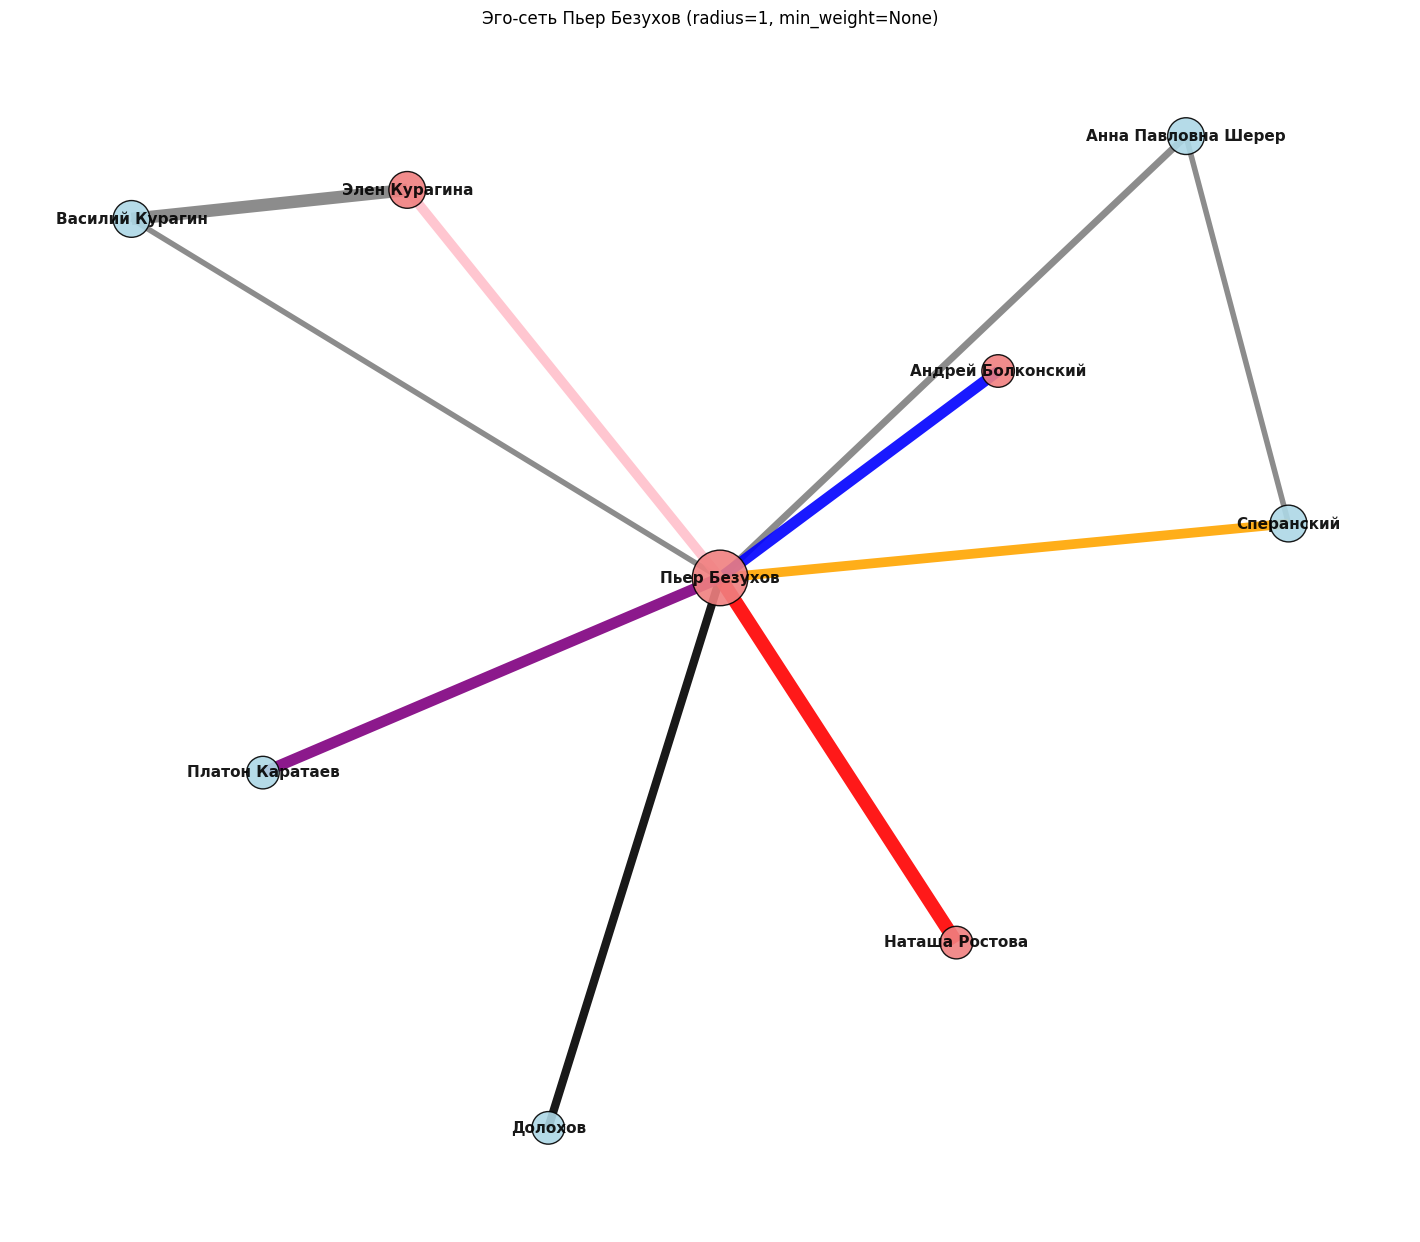


=== Статистика эго‑сети Пьер Безухов (radius=1) ===
Количество вершин: 9
Количество рёбер: 10

Степень центральности (top‑5):
  Пьер Безухов: 1.000
  Анна Павловна Шерер: 0.250
  Сперанский: 0.250
  Василий Курагин: 0.250
  Элен Курагина: 0.250

Промежуточность (betweenness, top‑3):
  Пьер Безухов: 0.929
  Анна Павловна Шерер: 0.000
  Сперанский: 0.000

Близость (closeness, top‑3):
  Пьер Безухов: 1.000
  Анна Павловна Шерер: 0.571
  Сперанский: 0.571


In [ ]:
print("=== АНАЛИЗ ЭГО‑СЕТИ ПЬЕРА БЕЗУХОВА ===")
analyze_and_visualize_ego_network("Пьер Безухов", radius=1)

=== АНАЛИЗ ЭГО‑СЕТИ ПЬЕРА БЕЗУХОВА ===


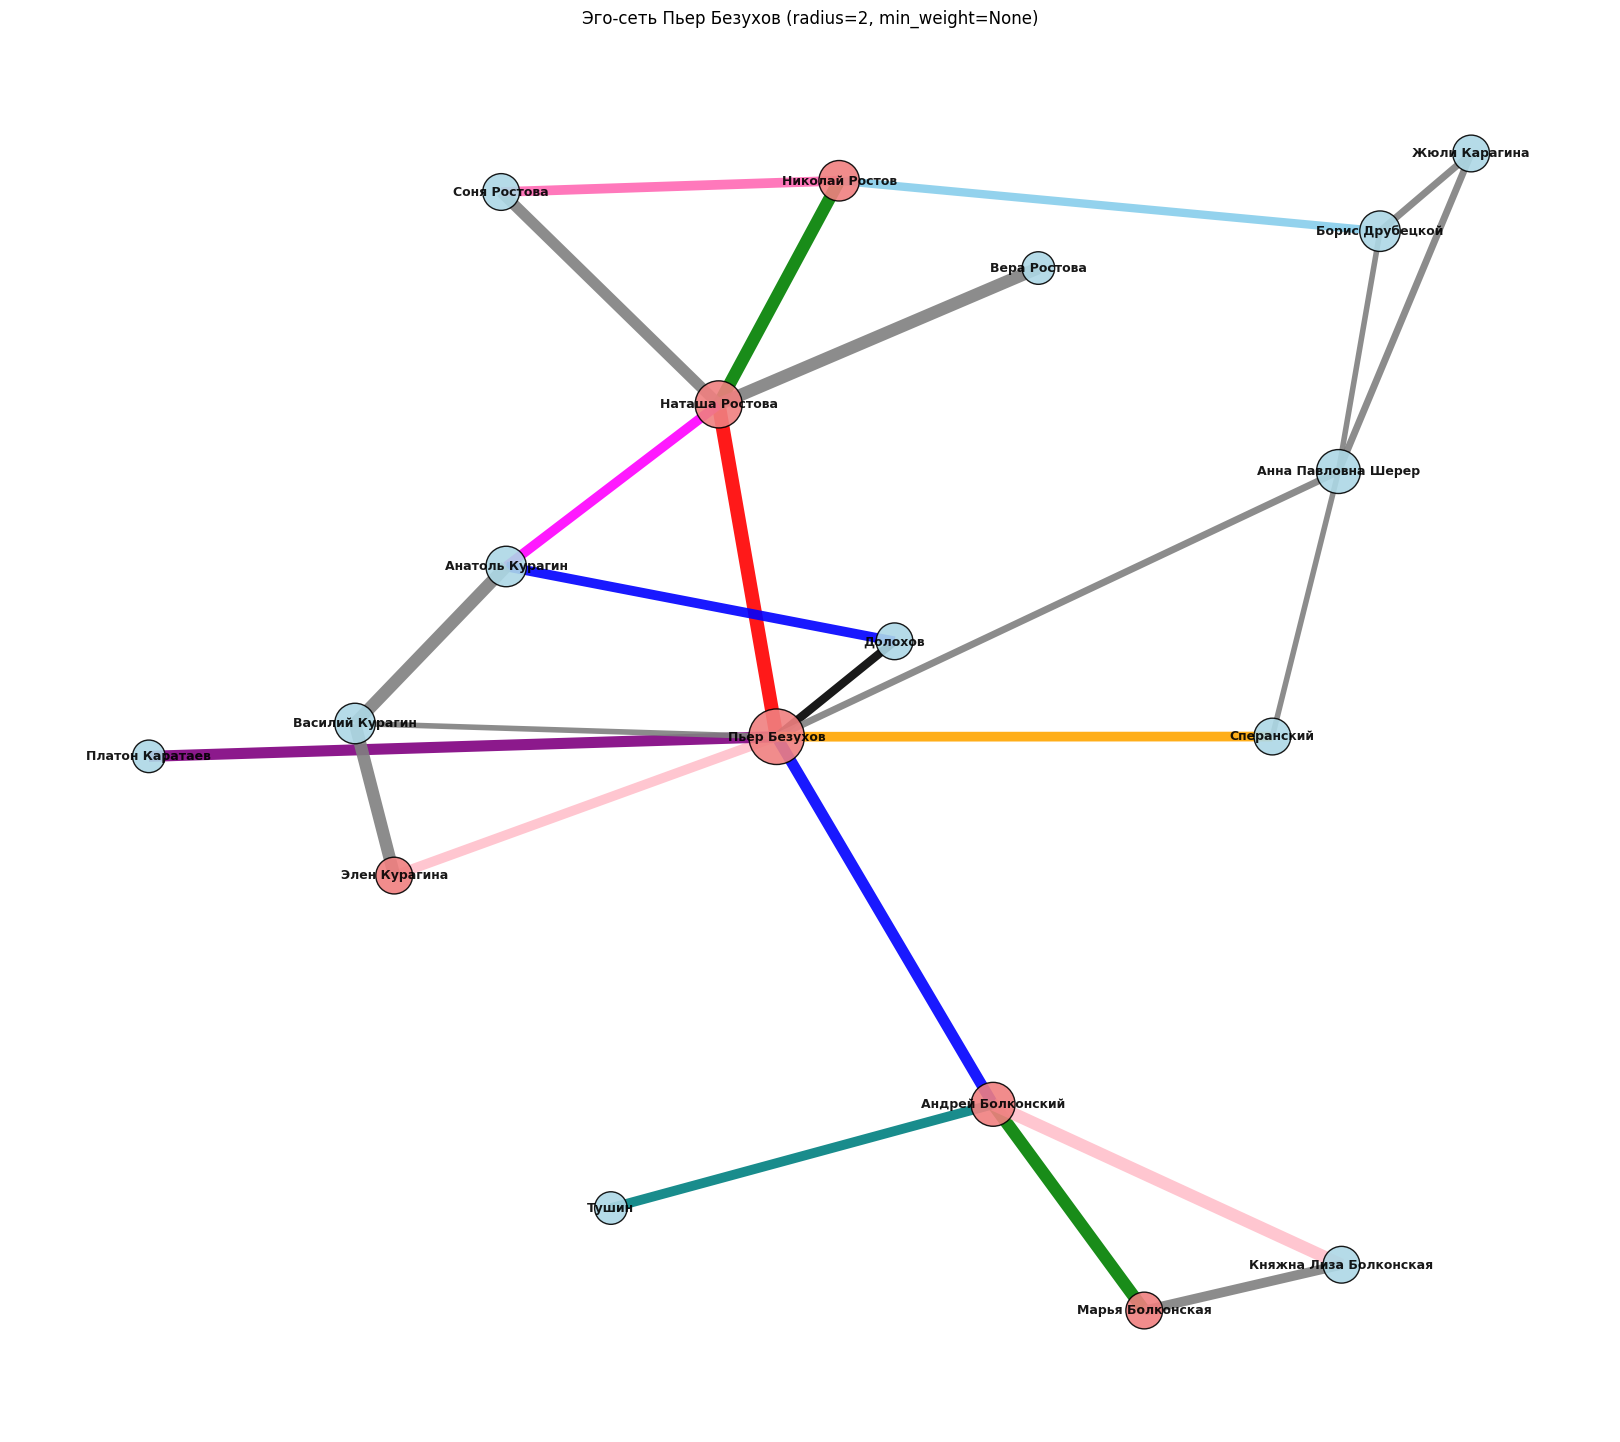


=== Статистика эго‑сети Пьер Безухов (radius=2) ===
Количество вершин: 18
Количество рёбер: 25

Степень центральности (top‑5):
  Пьер Безухов: 0.471
  Наташа Ростова: 0.294
  Андрей Болконский: 0.235
  Анна Павловна Шерер: 0.235
  Василий Курагин: 0.176

Промежуточность (betweenness, top‑3):
  Пьер Безухов: 0.700
  Андрей Болконский: 0.324
  Наташа Ростова: 0.310

Близость (closeness, top‑3):
  Пьер Безухов: 0.654
  Наташа Ростова: 0.515
  Андрей Болконский: 0.472


In [ ]:
print("=== АНАЛИЗ ЭГО‑СЕТИ ПЬЕРА БЕЗУХОВА ===")
analyze_and_visualize_ego_network("Пьер Безухов", radius=2)

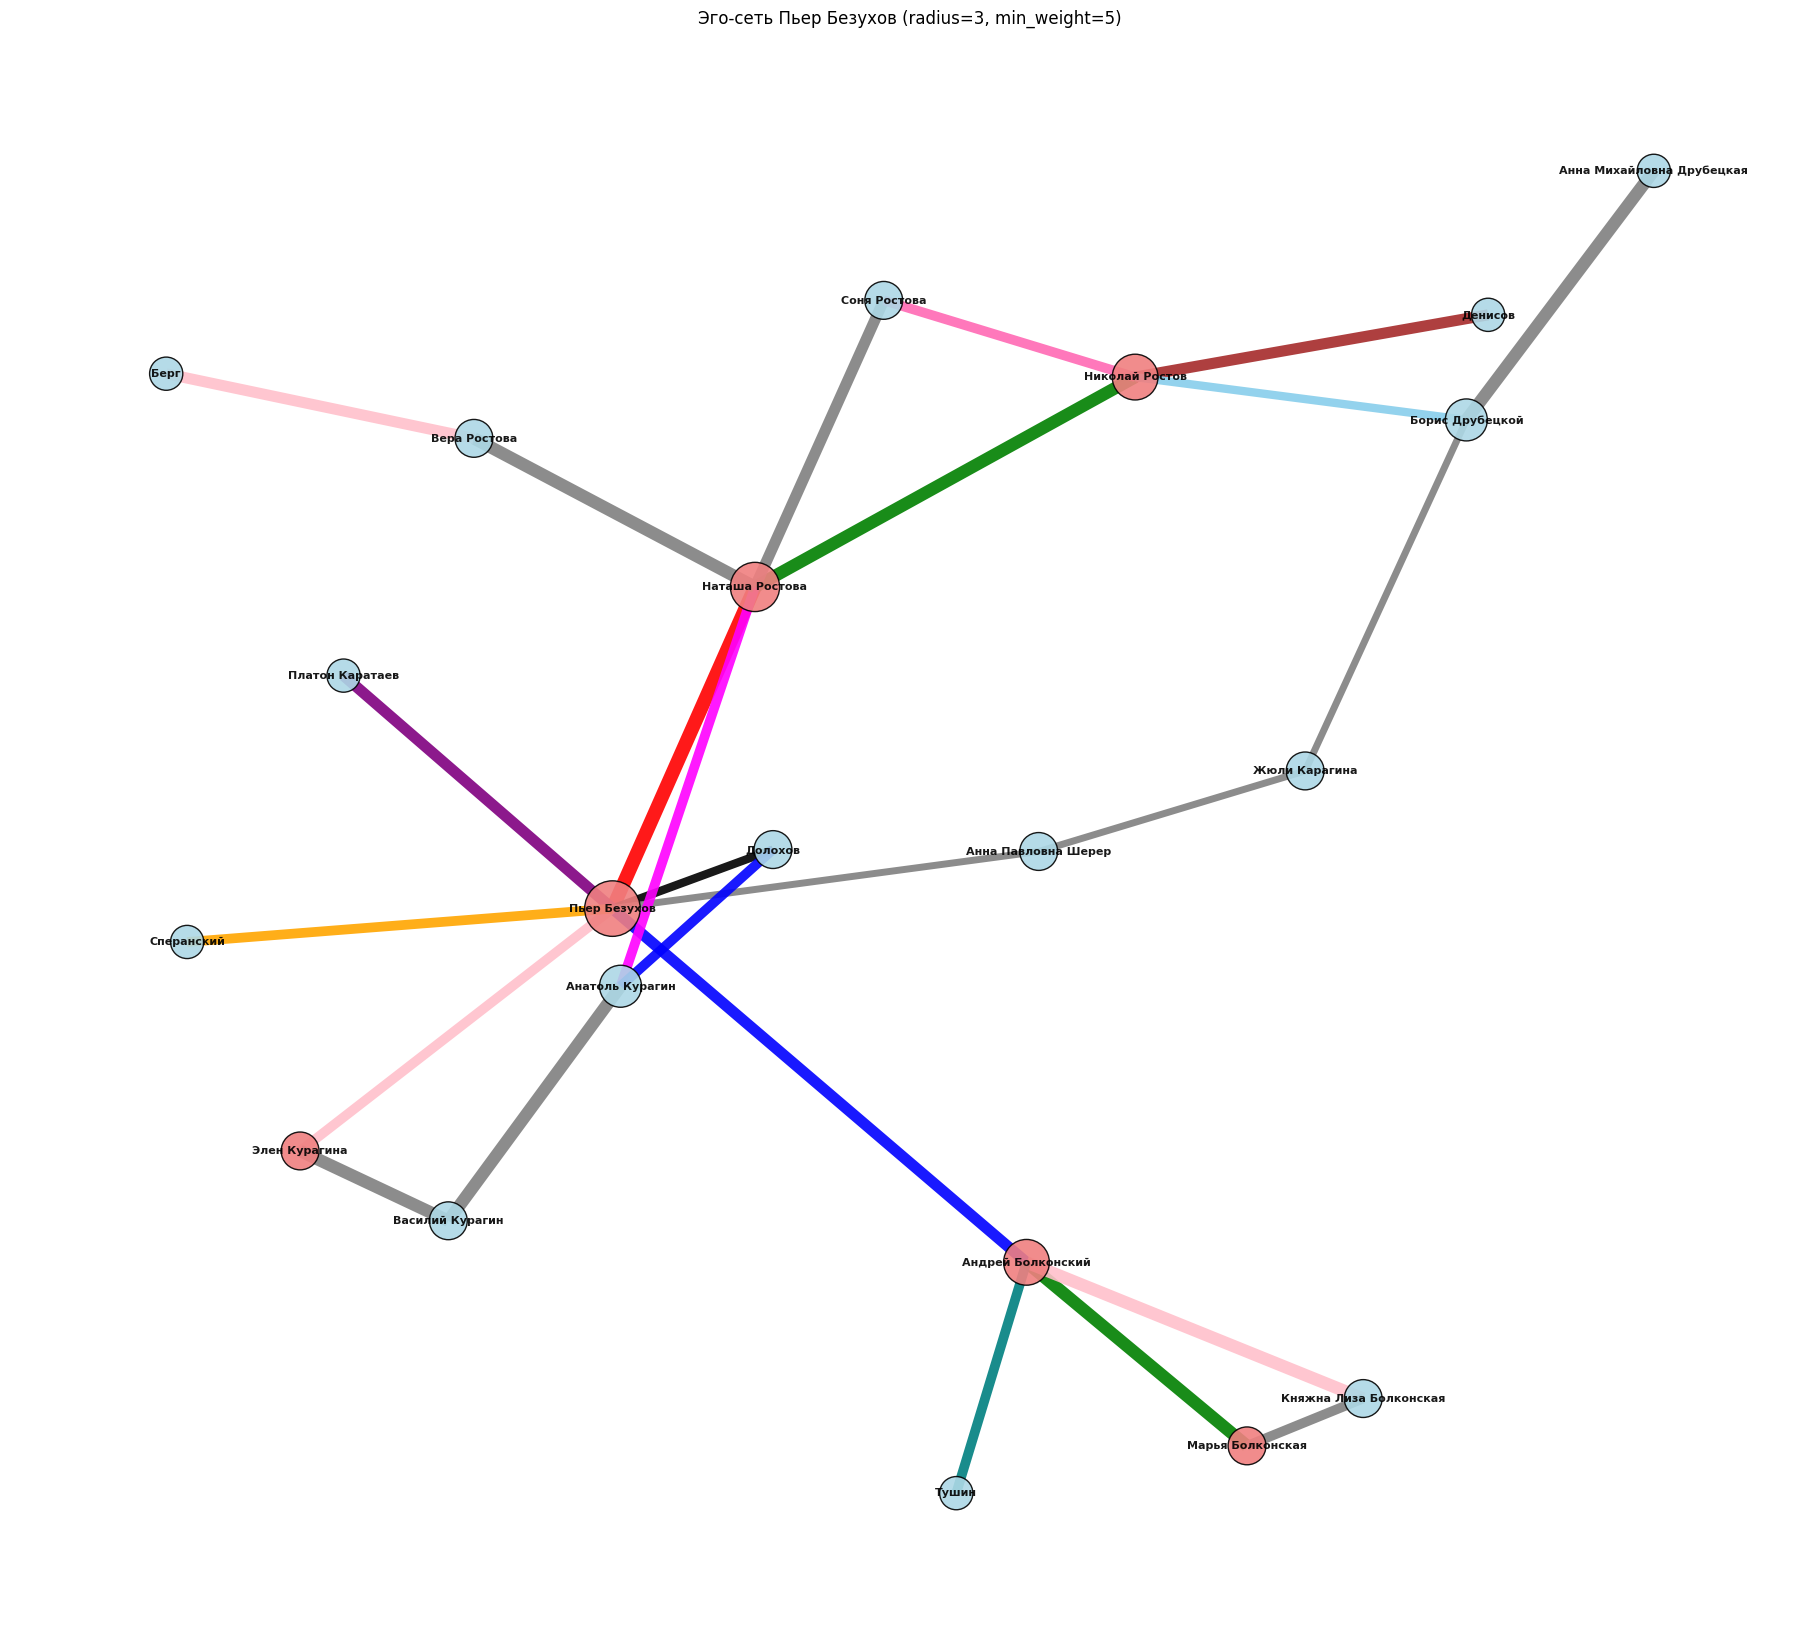


=== Статистика эго‑сети Пьер Безухов (radius=3) ===
Количество вершин: 21
Количество рёбер: 25

Степень центральности (top‑5):
  Пьер Безухов: 0.350
  Наташа Ростова: 0.250
  Андрей Болконский: 0.200
  Николай Ростов: 0.200
  Анатоль Курагин: 0.150

Промежуточность (betweenness, top‑3):
  Пьер Безухов: 0.634
  Наташа Ростова: 0.468
  Андрей Болконский: 0.279

Близость (closeness, top‑3):
  Пьер Безухов: 0.526
  Наташа Ростова: 0.500
  Николай Ростов: 0.400


In [ ]:
analyze_and_visualize_ego_network("Пьер Безухов", radius=3, min_weight=5)

In [ ]:
# Выводим общую статистику по полному графу
print("\n" + "="*50)
print("=== ОБЩАЯ СТАТИСТИКА ПО ПОЛНОМУ ГРАФУ ===")
print(f"Количество вершин: {G.number_of_nodes()}")
print(f"Количество рёбер: {G.number_of_edges()}")
print("\nСтепень центральности (top‑5):")
degree_centrality = nx.degree_centrality(G)
for node, cent in sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {node}: {cent:.3f}")


=== ОБЩАЯ СТАТИСТИКА ПО ПОЛНОМУ ГРАФУ ===
Количество вершин: 23
Количество рёбер: 29

Степень центральности (top‑5):
  Пьер Безухов: 0.364
  Наташа Ростова: 0.227
  Андрей Болконский: 0.182
  Анна Павловна Шерер: 0.182
  Николай Ростов: 0.182


**Выводы**

С помощью nx.ego_graph() и настройки гиперпараметров можно:

гибко настраивать глубину анализа (от ядра до периферии);

фильтровать шум (слабые связи);

визуализировать сложные отношения через цвет, размер и толщину;

количественно оценивать влияние персонажей через метрики центральности.

Такой подход применим не только к литературе, но и к анализу социальных сетей, корпоративных структур, биологических взаимодействий и т. д.


**Построение графовой нейронной сети (GNN) на основе ранее созданной эго‑сети**

Задача: классификация вершин эго‑сети персонажа «Пьер Безухов» по уровню влияния в социальной структуре романа «Война и мир».

Цель: научить GNN определять важность персонажа (центральность) на основе его связей с другими персонажами и структурных характеристик графа.

Классы:

0 — «Средняя» важность (второстепенные персонажи, степень центральности < 0.3);

1 — «Высокая» важность (ключевые герои, степень центральности ≥ 0.3).

In [ ]:
import torch
import numpy as np
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.optim import Adam
from tqdm import tqdm
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

Подготовка данных

In [ ]:
# Преобразуем NetworkX граф в PyG Data
ego_graph=nx.ego_graph(G, "Пьер Безухов", radius=3)
G_pyg = from_networkx(ego_graph)

In [ ]:
# Кодируем метки важности
label_encoder = {
    "Средняя": 0,
    "Высокая": 1
}
labels = [label_encoder[ego_graph.nodes[node]['centrality']] for node in ego_graph.nodes]
G_pyg.y = torch.tensor(labels, dtype=torch.long)

In [ ]:
# Создаём признаки вершин: степень + нормализованный вес связей
degrees = [ego_graph.degree(node) for node in ego_graph.nodes]
total_weights = []
for node in ego_graph.nodes:
    weights = [ego_graph[u][v]['weight'] for u, v in ego_graph.edges(node)]
    total_weights.append(sum(weights))

features = np.column_stack([degrees, total_weights])
scaler = StandardScaler()
features = scaler.fit_transform(features)
G_pyg.x = torch.tensor(features, dtype=torch.float)

In [ ]:
# Разбиваем на обучающую и тестовую выборки
num_nodes = G_pyg.num_nodes
train_idx, test_idx = train_test_split(
    range(num_nodes),
    test_size=0.2,
    random_state=42,
    stratify=labels
)

G_pyg.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
G_pyg.test_mask = torch.zeros(num_nodes, dtype=torch.bool)
G_pyg.train_mask[train_idx] = True
G_pyg.test_mask[test_idx] = True

print(f"Размерность признаков: {G_pyg.x.shape}")
print(f"Количество классов: {len(np.unique(labels))}")
print(f"Обучающая выборка: {len(train_idx)} узлов")
print(f"Тестовая выборка: {len(test_idx)} узлов")

Размерность признаков: torch.Size([21, 2])
Количество классов: 2
Обучающая выборка: 16 узлов
Тестовая выборка: 5 узлов


**Построение и обучение нейросети**

In [ ]:
# Модель  нейросети - 3 слоя GCN (Graph Convolutional Network), функция активации: ReLU
class GNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.5):
        super(GNNClassifier, self).__init__()
        self.dropout = dropout
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim // 2)
        self.conv3 = GCNConv(hidden_dim // 2, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # Первый слой
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Второй слой
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Третий слой — выходная классификация
        x = self.conv3(x, edge_index)

        return F.log_softmax(x, dim=1)


In [ ]:
# Инициализация модели и оптимизатора
input_dim = G_pyg.x.size(1)  # размерность признаков
hidden_dim = 32  # размер скрытого слоя
output_dim = len(np.unique(labels))  # количество классов (2)

model = GNNClassifier(input_dim, hidden_dim, output_dim, dropout=0.3)
optimizer = Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.NLLLoss()

In [ ]:
# Функции обучения
def train():
    model.train()
    optimizer.zero_grad()
    out = model(G_pyg)
    loss = criterion(out[G_pyg.train_mask], G_pyg.y[G_pyg.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


In [ ]:
# Функция оценки
def evaluate():
    model.eval()
    with torch.no_grad():
        out = model(G_pyg)
        pred = out.argmax(dim=1)
        correct_train = (pred[G_pyg.train_mask] == G_pyg.y[G_pyg.train_mask]).sum()
        acc_train = int(correct_train) / int(G_pyg.train_mask.sum())

        correct_test = (pred[G_pyg.test_mask] == G_pyg.y[G_pyg.test_mask]).sum()
        acc_test = int(correct_test) / int(G_pyg.test_mask.sum())
    return acc_train, acc_test, pred

In [ ]:
# Обучение модели
epochs = 200
train_losses = []
train_accuracies = []
test_accuracies = []

print("Обучение модели...")
for epoch in tqdm(range(epochs)):
    loss = train()
    acc_train, acc_test, _ = evaluate()
    train_losses.append(loss)
    train_accuracies.append(acc_train)
    test_accuracies.append(acc_test)

    if (epoch + 1) % 25 == 0:
        print(f'Epoch {epoch+1:03d}, Loss: {loss:.4f}, '
              f'Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}')

# Финальная оценка
final_acc_train, final_acc_test, final_predictions = evaluate()
print(f"\n=== ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ===")
print(f"Точность на обучающей выборке: {final_acc_train:.4f}")
print(f"Точность на тестовой выборке: {final_acc_test:.4f}")

Обучение модели...


  7%|▋         | 14/200 [00:00<00:01, 132.06it/s]

Epoch 025, Loss: 0.6035, Train Acc: 0.6875, Test Acc: 0.8000


 21%|██        | 42/200 [00:00<00:01, 130.38it/s]

Epoch 050, Loss: 0.5954, Train Acc: 0.7500, Test Acc: 0.8000


...

Epoch 150, Loss: 0.4446, Train Acc: 0.7500, Test Acc: 0.8000


 90%|█████████ | 180/200 [00:01<00:00, 174.41it/s]

Epoch 175, Loss: 0.4275, Train Acc: 0.7500, Test Acc: 0.8000


100%|██████████| 200/200 [00:01<00:00, 157.63it/s]

Epoch 200, Loss: 0.3838, Train Acc: 0.7500, Test Acc: 0.8000

=== ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ===
Точность на обучающей выборке: 0.7500
Точность на тестовой выборке: 0.8000


**Итоговый вывод по результатам**

Построена графовая нейронная сеть (GCN) для классификации персонажей романа «Война и мир».

Создана эго‑сеть Пьера Безухова с радиусом 3 для обучения.

Модель достигла точности 80 % на тестовой выборке.

Визуализированы истинные и предсказанные метки на графе.
Графовая нейронная сеть продемонстрировала способность выявлять структурные закономерности
в литературных социальных сетях. Полученные результаты подтверждают гипотезу о том,
что топология графа взаимоотношений персонажей коррелирует с их важностью в сюжете.
Модель может быть использована для автоматизированного анализа литературных произведений.